In [1]:
#install libraries
import subprocess
subprocess.run(['pip', 'install', 'matplotlib', 'seaborn', 'pandas', 'openpyxl'], check=True)
print('Done')

Done


In [2]:
#load all libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('Libraries loaded')

Libraries loaded


In [ ]:
#load datasets
folder = "your_folder_path/"
master   = pd.read_csv(folder + 'master_daily.csv', parse_dates=['Date'])
nvda     = pd.read_csv(folder + 'nvda_stock_price.csv', parse_dates=['Date'])
qqq      = pd.read_csv(folder + 'qqq_price.csv', parse_dates=['Date'])
amd      = pd.read_csv(folder + 'amd_stock_price.csv', parse_dates=['Date'])
intc     = pd.read_csv(folder + 'intc_stock_price.csv', parse_dates=['Date'])
segment  = pd.read_csv(folder + 'nvda_revenue_by_segment.csv')
milestones = pd.read_csv(folder + 'ai_milestone_log.csv', parse_dates=['date'])
pe       = pd.read_excel(folder + 'nvda_pe_ratio.xlsx')
mktcap   = pd.read_csv(folder + 'nvda_market_cap.csv')
print('All datasets loaded successfully')

All datasets loaded successfully


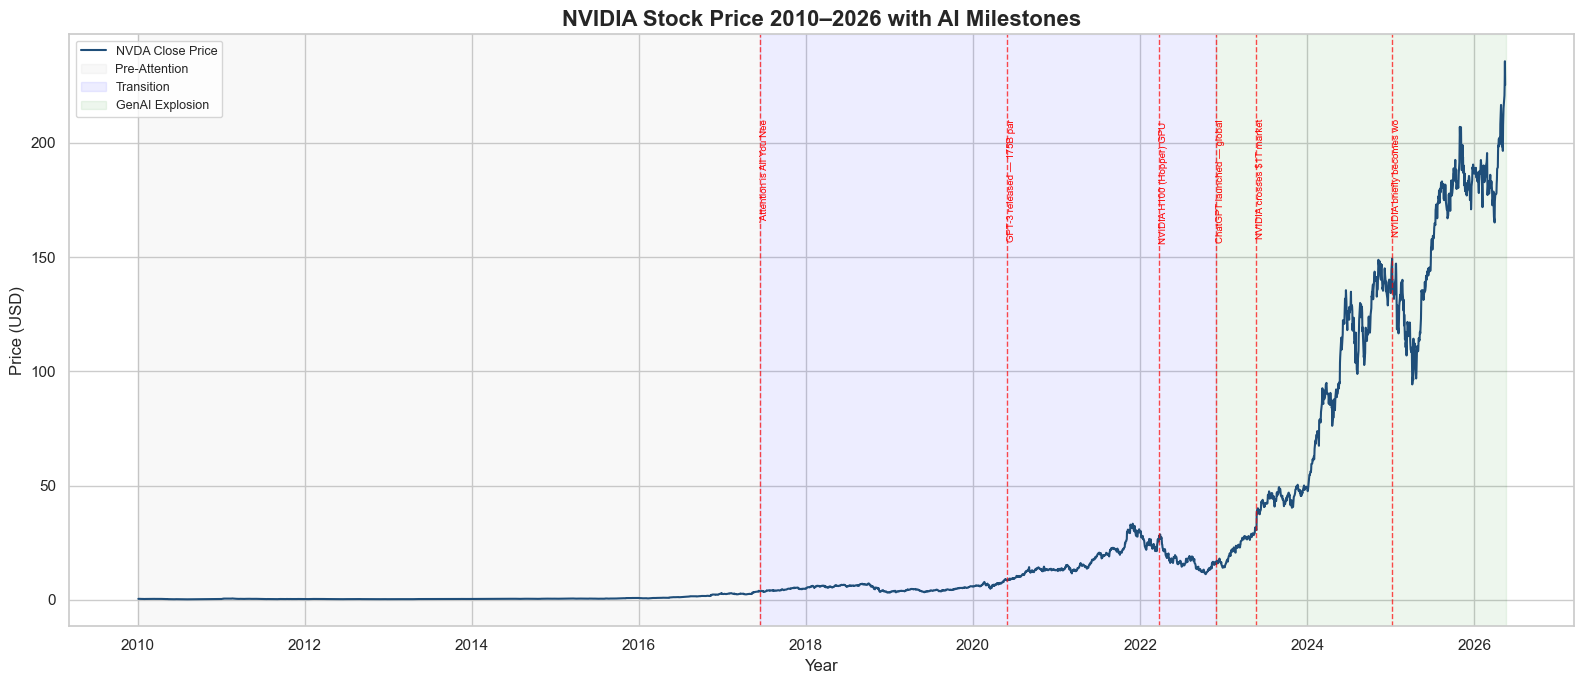

In [10]:
#Nvidia stock price with milestones
fig, ax = plt.subplots(figsize=(16, 7))

# Plot NVDA price
ax.plot(nvda['Date'], nvda['Close'], color='#1F4E79', linewidth=1.5, label='NVDA Close Price')

# Shade the 3 epochs
ax.axvspan(pd.Timestamp('2010-01-01'), pd.Timestamp('2017-06-12'), alpha=0.05, color='gray', label='Pre-Attention')
ax.axvspan(pd.Timestamp('2017-06-12'), pd.Timestamp('2022-11-30'), alpha=0.07, color='blue', label='Transition')
ax.axvspan(pd.Timestamp('2022-11-30'), pd.Timestamp('2026-05-17'), alpha=0.07, color='green', label='GenAI Explosion')

# Add milestone lines — only Critical ones to keep chart clean
critical = milestones[milestones['significance'] == 'Critical']
for _, row in critical.iterrows():
    ax.axvline(x=row['date'], color='red', linestyle='--', alpha=0.7, linewidth=1)
    ax.text(row['date'], ax.get_ylim()[1]*0.85, row['event'][:25],
            rotation=90, fontsize=7, color='red', va='top')

ax.set_title('NVIDIA Stock Price 2010–2026 with AI Milestones', fontsize=16, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Price (USD)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('chart1_nvda_price.png', dpi=150, bbox_inches='tight')
plt.show()

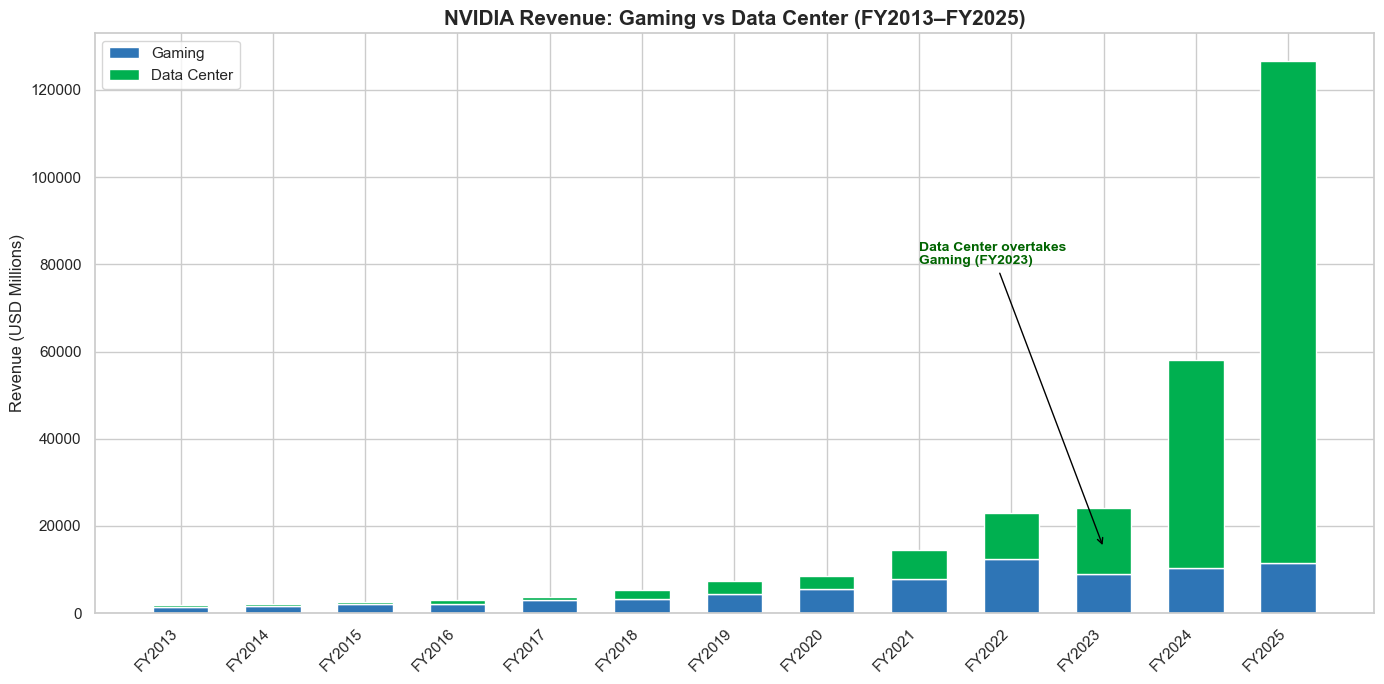

In [11]:
#gaming vs data centre revenue
fig, ax = plt.subplots(figsize=(14, 7))

x = range(len(segment))
ax.bar(x, segment['gaming'],      label='Gaming',       color='#2E75B6', width=0.6)
ax.bar(x, segment['data_center'], label='Data Center',  color='#00B050', width=0.6,
       bottom=segment['gaming'])

ax.set_xticks(x)
ax.set_xticklabels(segment['period'], rotation=45, ha='right')
ax.set_title('NVIDIA Revenue: Gaming vs Data Center (FY2013–FY2025)', fontsize=15, fontweight='bold')
ax.set_ylabel('Revenue (USD Millions)')
ax.legend()

# Annotate the crossover
ax.annotate('Data Center overtakes\nGaming (FY2023)',
            xy=(10, segment['data_center'].iloc[10]),
            xytext=(8, 80000),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, color='darkgreen', fontweight='bold')

plt.tight_layout()
plt.savefig('chart2_segment_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
#p/e ratio over time
# First check your column names — run this cell alone first
print(pe.columns.tolist())
print(pe.head(3))

['date', 'stock price', 'TTM Net EPS', 'PE Ratio']
        date  stock price  TTM Net EPS  PE Ratio
0 2026-05-15       225.32          NaN     45.98
1 2026-01-31       191.12         4.90     39.00
2 2025-10-31       202.47         4.03     50.24


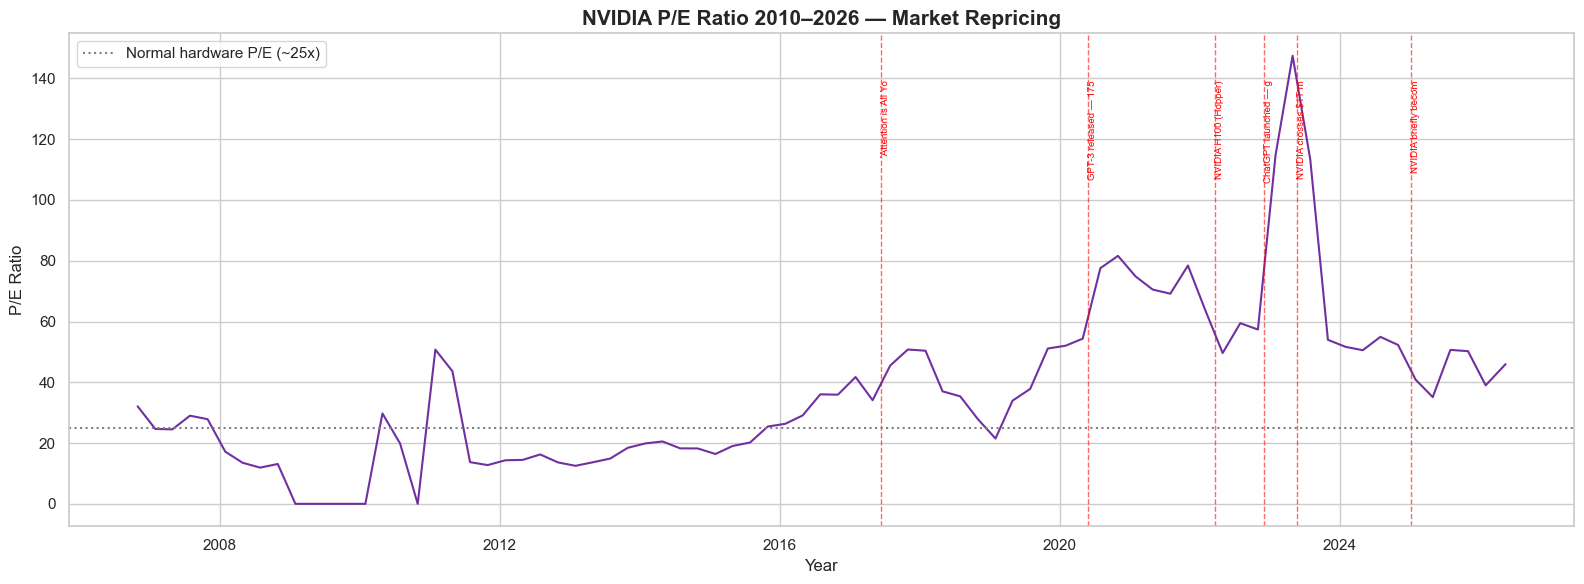

In [14]:
fig, ax = plt.subplots(figsize=(16, 6))

pe['date'] = pd.to_datetime(pe['date'])   
ax.plot(pe['date'], pe['PE Ratio'], color='#7030A0', linewidth=1.5) 

# Add milestone lines
critical = milestones[milestones['significance'] == 'Critical']
for _, row in critical.iterrows():
    ax.axvline(x=row['date'], color='red', linestyle='--', alpha=0.6, linewidth=1)
    ax.text(row['date'], ax.get_ylim()[1]*0.9, row['event'][:20],
            rotation=90, fontsize=7, color='red', va='top')

ax.axhline(y=25, color='gray', linestyle=':', linewidth=1.5, label='Normal hardware P/E (~25x)')
ax.set_title('NVIDIA P/E Ratio 2010–2026 — Market Repricing', fontsize=15, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('P/E Ratio')
ax.legend()
plt.tight_layout()
plt.savefig('chart3_pe_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

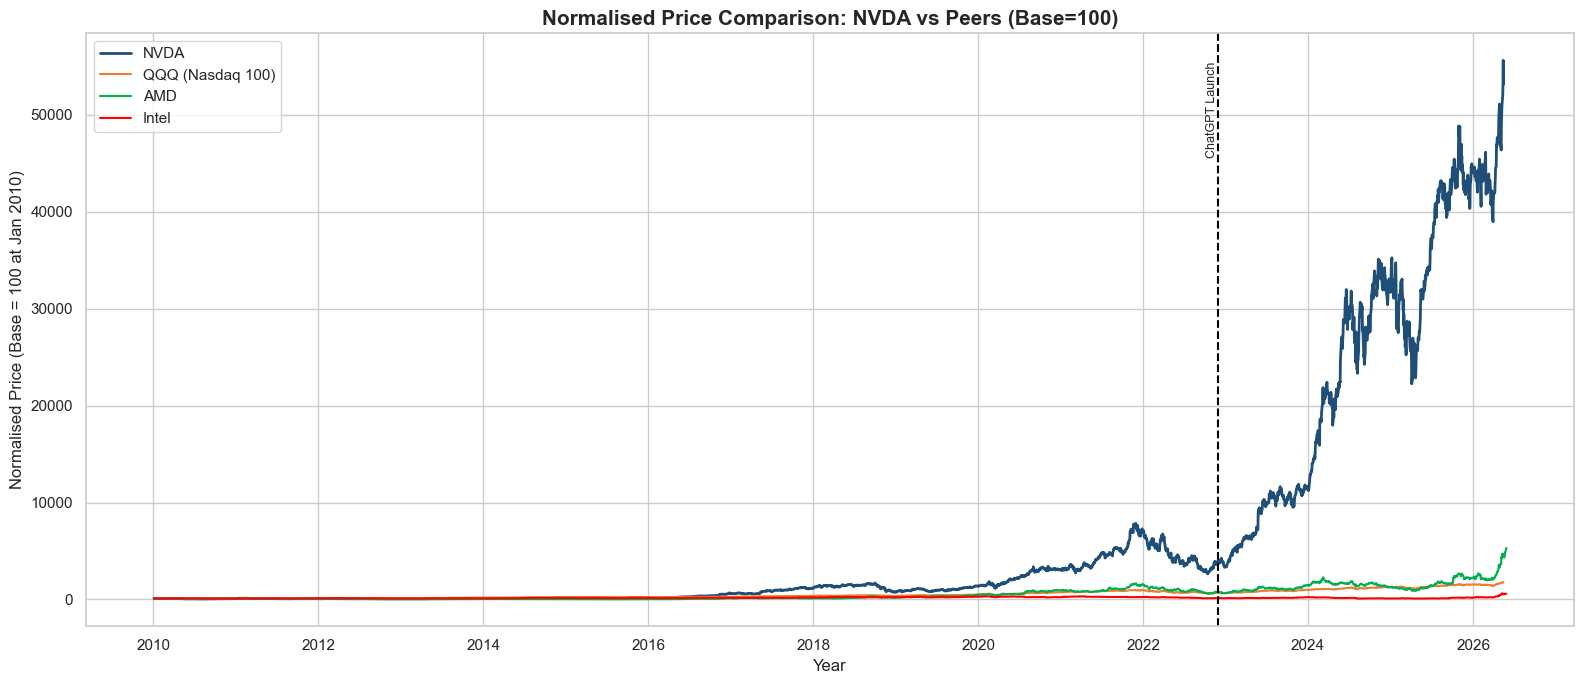

In [15]:
#NVDA vs QQQ vs AMD vs Intel
# Normalise all prices to 100 at start date
def normalise(df, col='Close'):
    return (df[col] / df[col].iloc[0]) * 100

fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(nvda['Date'],  normalise(nvda),  color='#1F4E79', linewidth=2,   label='NVDA')
ax.plot(qqq['Date'],   normalise(qqq),   color='#ED7D31', linewidth=1.5, label='QQQ (Nasdaq 100)')
ax.plot(amd['Date'],   normalise(amd),   color='#00B050', linewidth=1.5, label='AMD')
ax.plot(intc['Date'],  normalise(intc),  color='#FF0000', linewidth=1.5, label='Intel')

# ChatGPT launch marker
ax.axvline(x=pd.Timestamp('2022-11-30'), color='black', linestyle='--', linewidth=1.5)
ax.text(pd.Timestamp('2022-11-30'), ax.get_ylim()[1]*0.95, 'ChatGPT Launch',
        fontsize=9, rotation=90, va='top', ha='right')

ax.set_title('Normalised Price Comparison: NVDA vs Peers (Base=100)', fontsize=15, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Normalised Price (Base = 100 at Jan 2010)')
ax.legend()
plt.tight_layout()
plt.savefig('chart4_normalised_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
#NVDA Market Cap Over Time
# Check columns first
print(mktcap.columns.tolist())
print(mktcap.head(3))

['date', 'open', 'high', 'low', 'close', 'volume']
         date    open    high     low   close   volume
0  1999-01-22  0.0401  0.0448  0.0356  0.0376  5186596
1  1999-01-25  0.0405  0.0420  0.0376  0.0415   974288
2  1999-01-26  0.0420  0.0428  0.0377  0.0383   655131


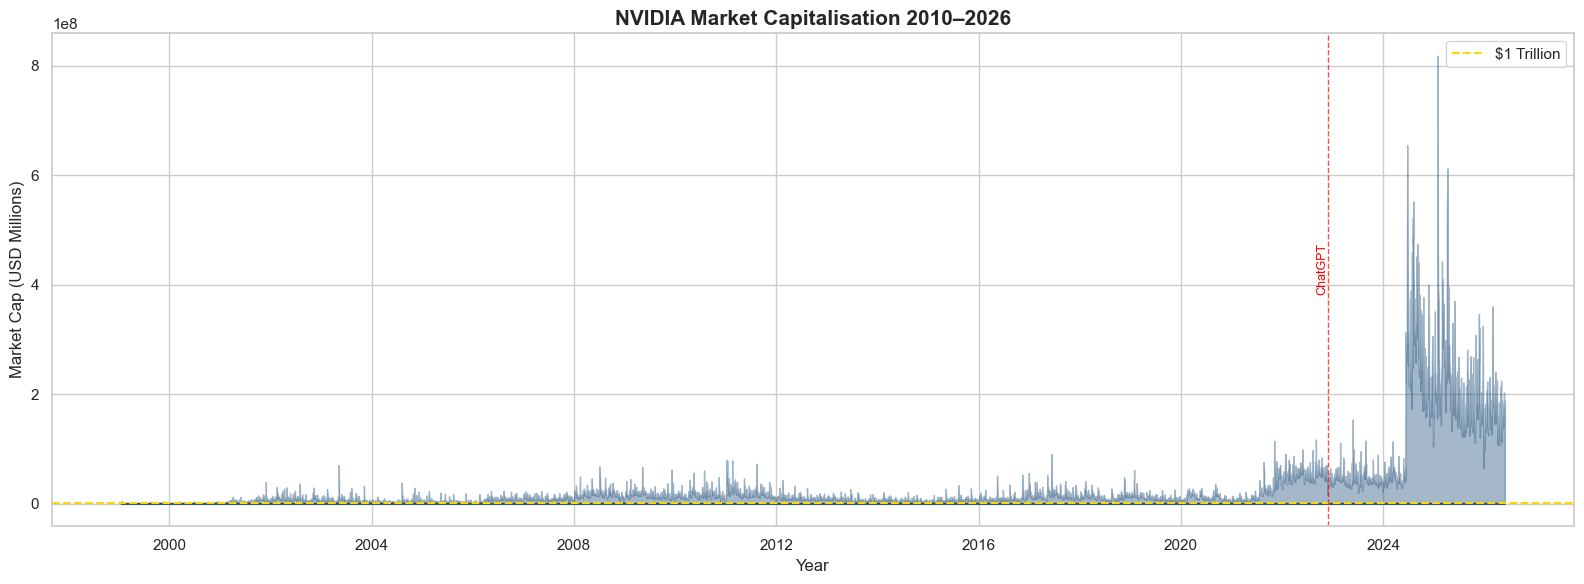

In [20]:
fig, ax = plt.subplots(figsize=(16, 6))

mktcap['date'] = pd.to_datetime(mktcap['date'])   # replace with your date column
ax.fill_between(mktcap['date'], mktcap['volume'],  # replace 'MarketCap'
                color='#1F4E79', alpha=0.4)
ax.plot(mktcap['date'], mktcap['close'], color='#1F4E79', linewidth=1.5)

# $1 trillion milestone
ax.axhline(y=1000000, color='gold', linestyle='--', linewidth=1.5, label='$1 Trillion')
ax.axvline(x=pd.Timestamp('2022-11-30'), color='red', linestyle='--', linewidth=1, alpha=0.7)
ax.text(pd.Timestamp('2022-11-30'), ax.get_ylim()[1]*0.5, 'ChatGPT',
        fontsize=9, rotation=90, va='center', ha='right', color='red')

ax.set_title('NVIDIA Market Capitalisation 2010–2026', fontsize=15, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Market Cap (USD Millions)')
ax.legend()
plt.tight_layout()
plt.savefig('chart5_market_cap.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
#epoch table
stats = master.groupby('Epoch')['NVDA_Return'].agg(
    Mean_Return='mean',
    Volatility='std',
    Min_Return='min',
    Max_Return='max',
    Trading_Days='count'
).round(6)

# Convert to percentages for readability
stats = stats * 100
stats['Trading_Days'] = stats['Trading_Days'].round(0).astype(int)

print(stats.to_string())
stats.to_csv('table1_summary_stats.csv')
print('Saved to table1_summary_stats.csv')

                                  Mean_Return  Volatility  Min_Return  Max_Return  Trading_Days
Epoch                                                                                          
GenAI Explosion (2022–present)         0.3557      3.1034    -16.9682     24.3696         86700
Pre-Attention (2010–2017)              0.1464      2.5020    -11.5358     29.8067        187100
Transition / Scaling (2017–2022)       0.1550      3.1625    -18.7559     17.1565        137800
Saved to table1_summary_stats.csv


In [22]:
#save
import os
outputs = [
    'chart1_nvda_price.png',
    'chart2_segment_revenue.png',
    'chart3_pe_ratio.png',
    'chart4_normalised_comparison.png',
    'chart5_market_cap.png',
    'table1_summary_stats.csv'
]
for f in outputs:
    status = 'OK' if os.path.exists(f) else 'MISSING'
    print(f'{status}  {f}')

OK  chart1_nvda_price.png
OK  chart2_segment_revenue.png
OK  chart3_pe_ratio.png
OK  chart4_normalised_comparison.png
OK  chart5_market_cap.png
OK  table1_summary_stats.csv
